<a href="https://colab.research.google.com/github/aniqarahman/portfolio/blob/main/diabetes_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font size="5"> Importing and Setting Up Data/Libraries </font>

In [ ]:
import sys
print(sys.executable)

/Library/Developer/CommandLineTools/usr/bin/python3


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model as lm
from sklearn.preprocessing import OneHotEncoder

In [ ]:
diabetes = pd.read_csv('/Users/aniqa/Downloads/diabetes.csv')
diabetes

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


In [ ]:
diabetes.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [ ]:
def diabetes_num_to_words(num):
    if num == 0:
        return "No Diabetes"
    if num == 1:
        return "Pre-Diabetic"
    if num == 2:
        return "Diabetic"


diabetes['Diabetes?'] = diabetes['Diabetes_012'].apply(diabetes_num_to_words)
diabetes

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes?
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0,No Diabetes
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0,No Diabetes
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0,No Diabetes
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0,No Diabetes
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0,No Diabetes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0,No Diabetes
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0,Diabetic
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0,No Diabetes
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0,No Diabetes


In [ ]:
phys_health = diabetes.groupby('Diabetes_012')['PhysHlth'].mean()
phys_health



Diabetes_012
0.0    3.582416
1.0    6.348305
2.0    7.954479
Name: PhysHlth, dtype: float64

<Axes: xlabel='HighBP', ylabel='BMI'>

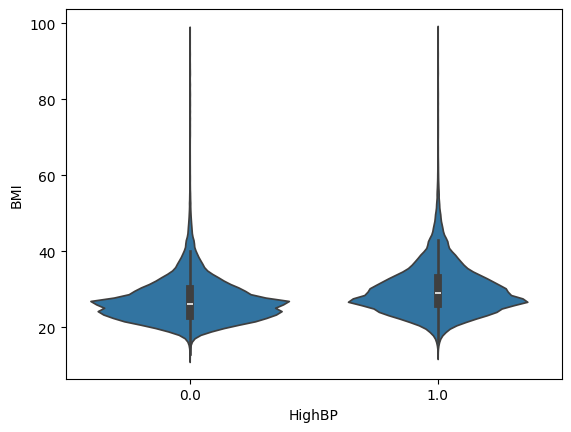

In [ ]:
sns.violinplot(x = "HighBP", y = "BMI", data = diabetes)

<font size="5"> EDA </font>

In [ ]:
#checking if there are any null values I need to account for in the data
for column in diabetes.columns:
    num_of_null_vals = diabetes[column].isna().sum()
    print(column, num_of_null_vals)

#there are 0 columns with null values

Diabetes_012 0
HighBP 0
HighChol 0
CholCheck 0
BMI 0
Smoker 0
Stroke 0
HeartDiseaseorAttack 0
PhysActivity 0
Fruits 0
Veggies 0
HvyAlcoholConsump 0
AnyHealthcare 0
NoDocbcCost 0
GenHlth 0
MentHlth 0
PhysHlth 0
DiffWalk 0
Sex 0
Age 0
Education 0
Income 0
Diabetes? 0


First, I'm going to explore how BMI ranges between non-diabetic, pre-diabetic, and diabetic patients using three histograms, since the data is quantative.

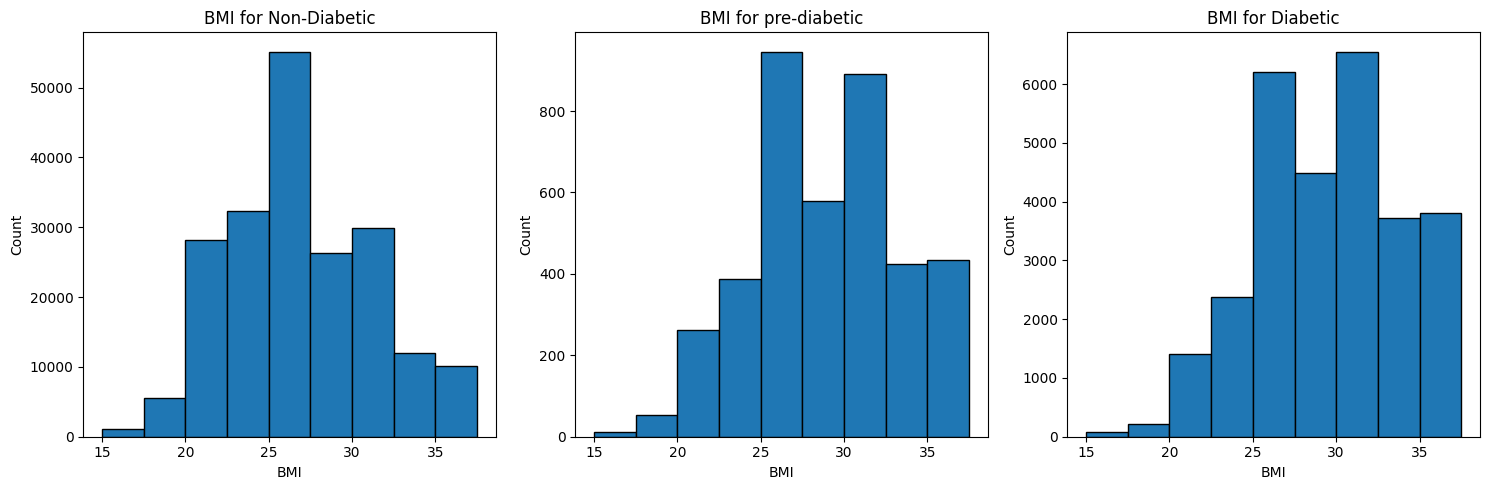

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

not_diabetic = diabetes[diabetes['Diabetes?'] == "No Diabetes"]
axes[0].hist(not_diabetic['BMI'], bins = np.arange(15,40,2.5), edgecolor='black')
axes[0].set_title('BMI for Non-Diabetic')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Count')

pre_diabetic = diabetes[diabetes['Diabetes?'] == "Pre-Diabetic"]
axes[1].hist(pre_diabetic['BMI'], bins = np.arange(15,40,2.5), edgecolor='black')
axes[1].set_title('BMI for pre-diabetic')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Count')

diabetic = diabetes[diabetes['Diabetes?'] == "Diabetic"]
axes[2].hist(diabetic['BMI'], bins = np.arange(15,40,2.5), edgecolor='black')
axes[2].set_title('BMI for Diabetic')
axes[2].set_xlabel('BMI')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()



For the non-diabetic graph, the graph is slightly more left-leaning, with the right side tapering off. The highest peack is between the 25-27.5 BMI bin. Comparatively, the diabetic and pre-diabetic graphs have higher amounts of people in BMIs beyond 30, which is the range for obesity according to the National Heart, Lung, and Blood Institute. Both have a peak in the graph in the 30-32.5 BMI bin. With these observations, BMI would be a good feature to use to predict how lifestyle indicators can affect the risk of diabetes.

In [ ]:
features = []
features.append('BMI')
#Every time I find a

In [ ]:
def diabetes_barplots(column):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    not_diabetic = diabetes[diabetes['Diabetes?'] == "No Diabetes"]
    sns.countplot(x=column, data=not_diabetic, ax = axes[0])
    axes[0].set_title(column + ' (Non-Diabetic)')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Count')

    pre_diabetic = diabetes[diabetes['Diabetes?'] == "Pre-Diabetic"]
    sns.countplot(x=column, data=pre_diabetic, ax = axes[1])
    axes[1].set_title(column + ' (Pre-Diabetic)')
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Count')

    diabetic = diabetes[diabetes['Diabetes?'] == "Diabetic"]
    sns.countplot(x=column, data=diabetic, ax = axes[2])
    axes[2].set_title(column + ' (Diabetic)')
    axes[2].set_xlabel(column)
    axes[2].set_ylabel('Count')

    plt.tight_layout()
    plt.show()

#this function automates my ability to see different binary health indicators like HighBP among the three diabetic groups

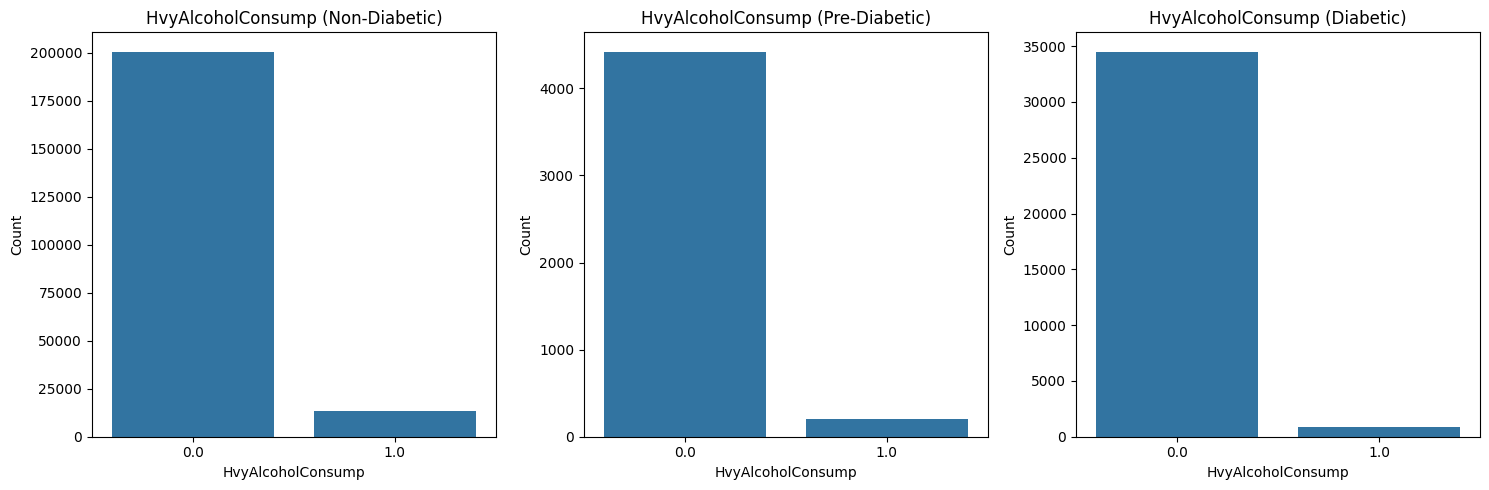

In [ ]:
diabetes_barplots("HvyAlcoholConsump")
#no significant difference so this feature will not be used

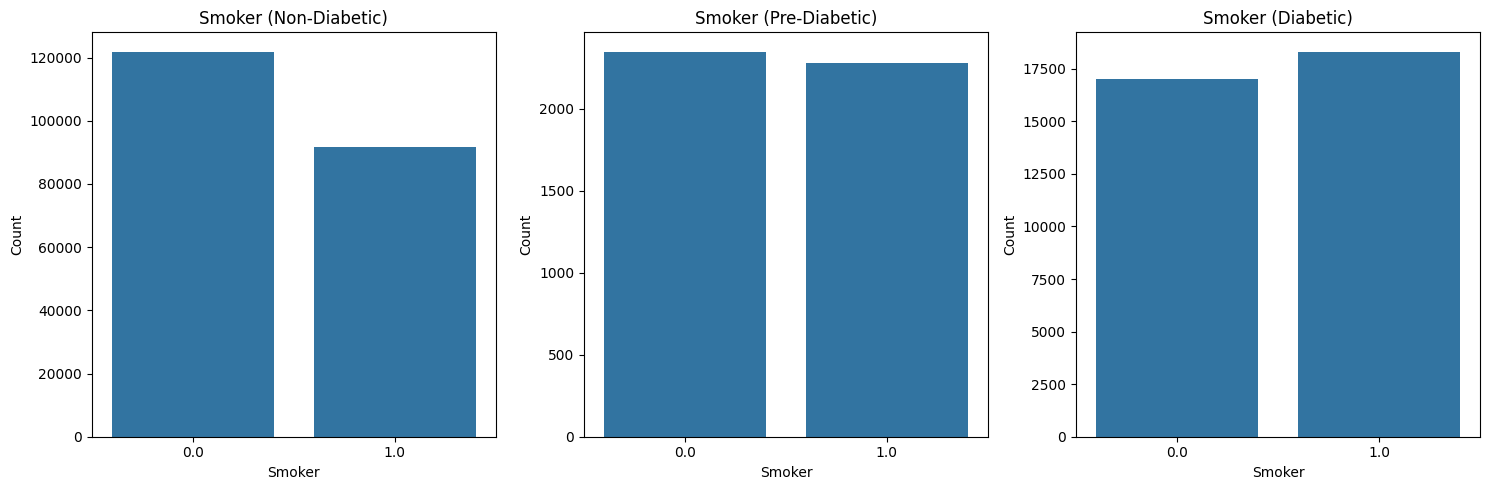

In [ ]:
diabetes_barplots("Smoker")
features.append("Smoker")

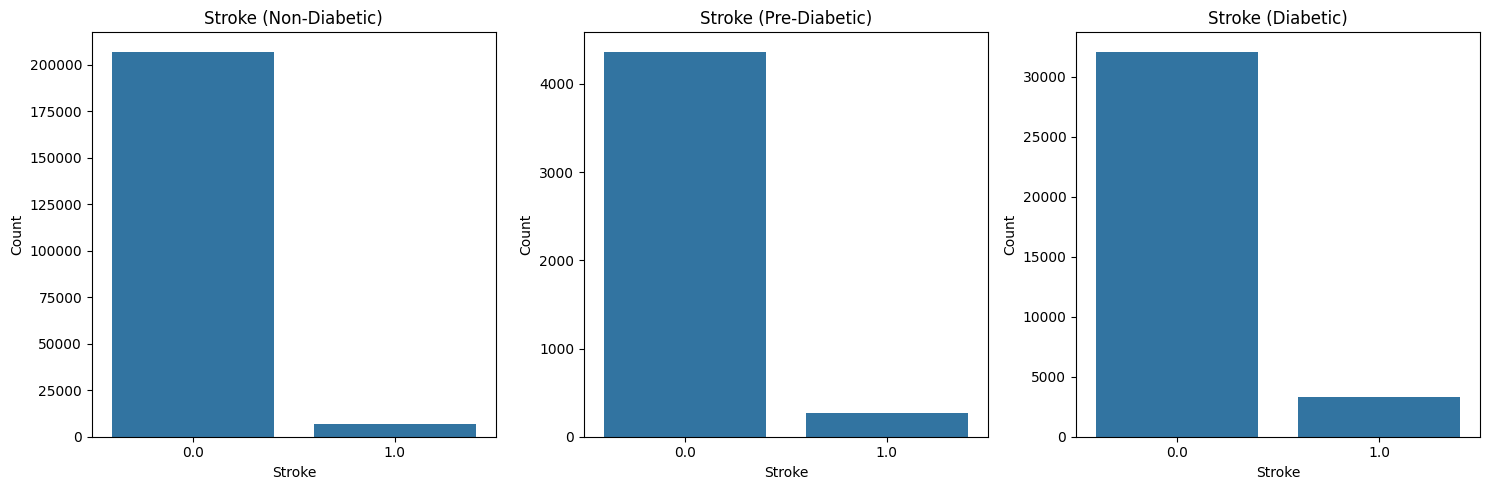

In [ ]:
diabetes_barplots("Stroke")


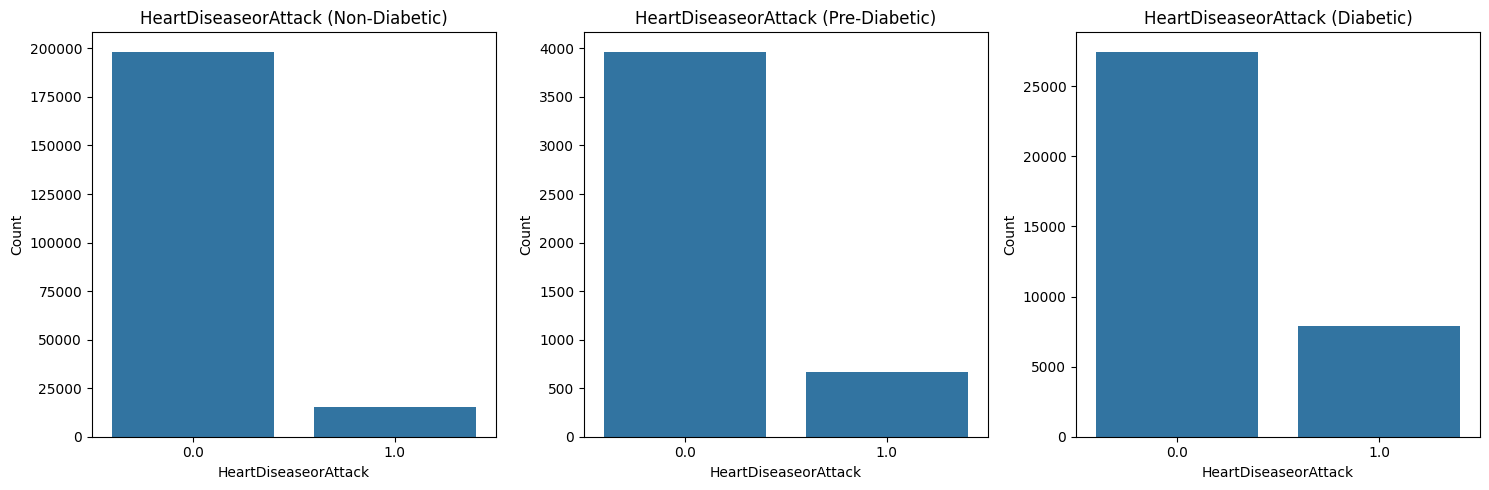

In [ ]:
diabetes_barplots("HeartDiseaseorAttack")
#coronary heart disease (CHD) or myocardial infarction (MI) 0 = no 1 = yes.
#worth noting the diabetes plot has a higher count of heat attack/disease. This could be a good feature to add.
features.append("HeartDiseaseorAttack")

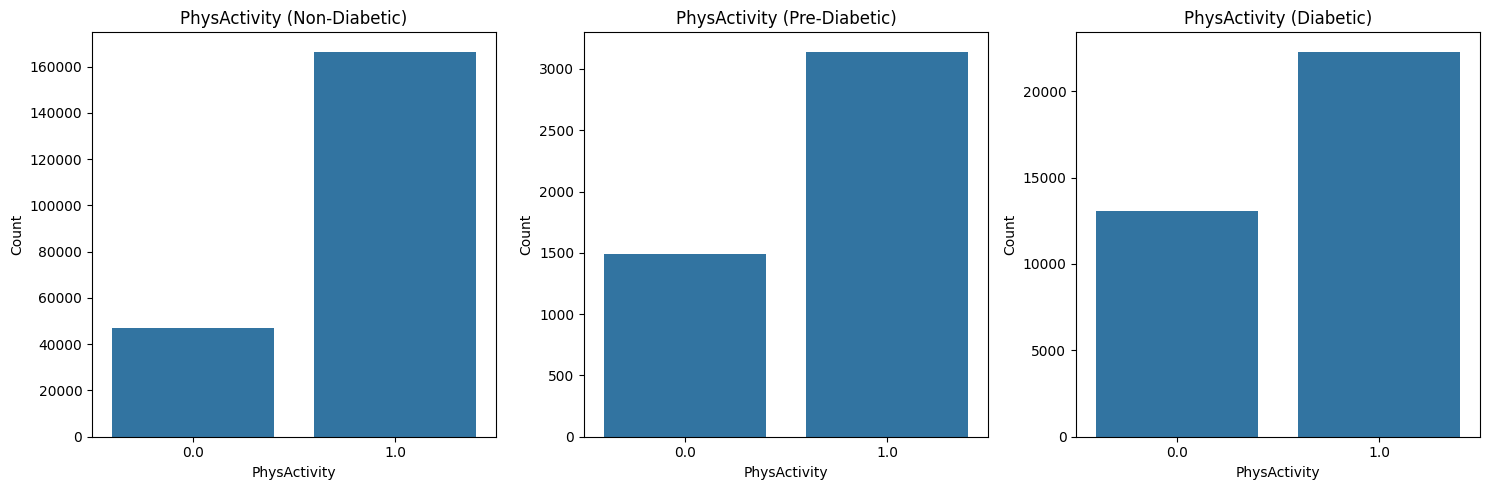

In [ ]:
diabetes_barplots("PhysActivity")
#yes = 1, no = 0. It might be natural to believe that non-diabetic people lead a healthier lifestyle but data
#does not match that. I will NOT be using this as this won't be an accurate indicator for diabetes risk
features.append("PhysActivity")

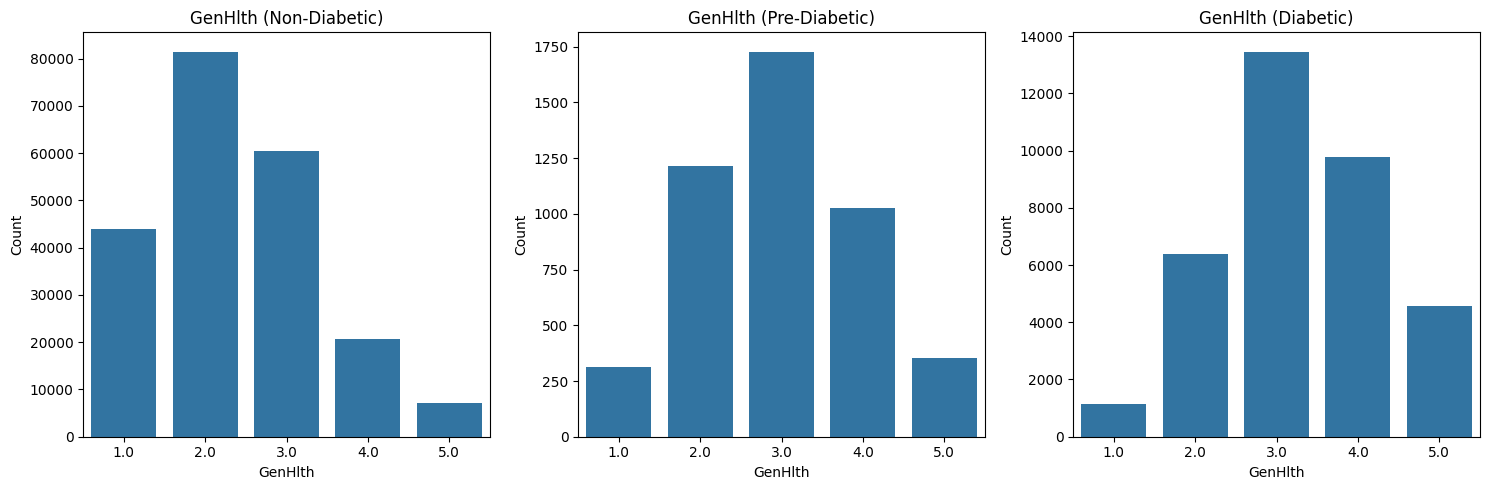

In [ ]:
diabetes_barplots("GenHlth")
#1 being good, 5 being poor. this one can be used but unsure of how it will perform on test set
features.append("GenHlth")

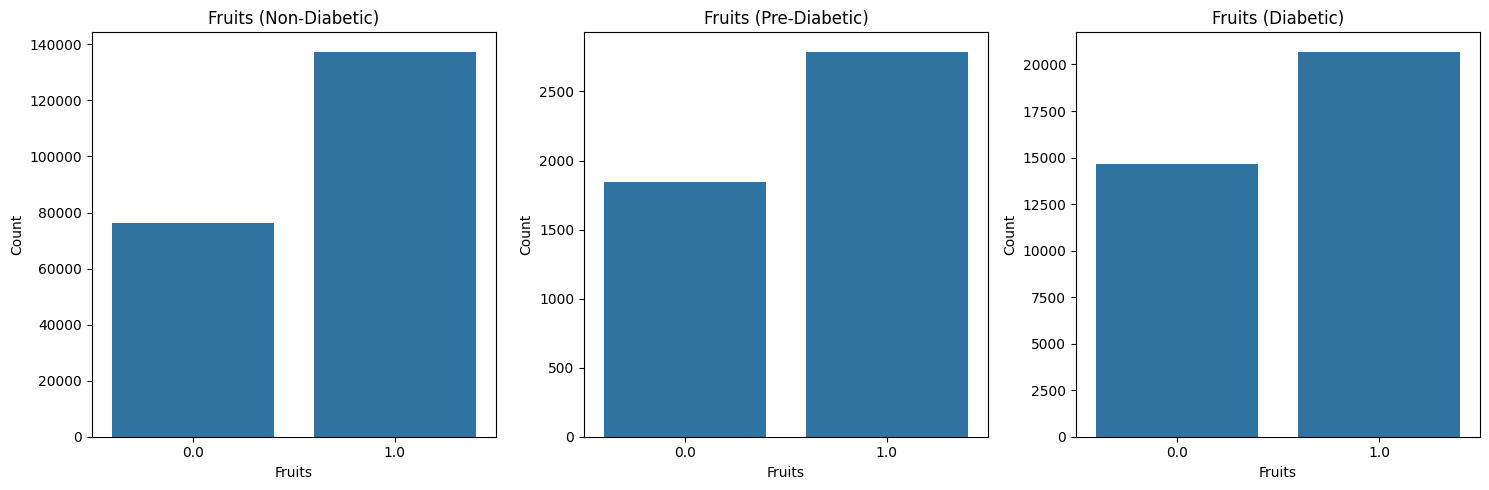

In [ ]:
diabetes_barplots("Fruits")
#0 = no 1 = yes


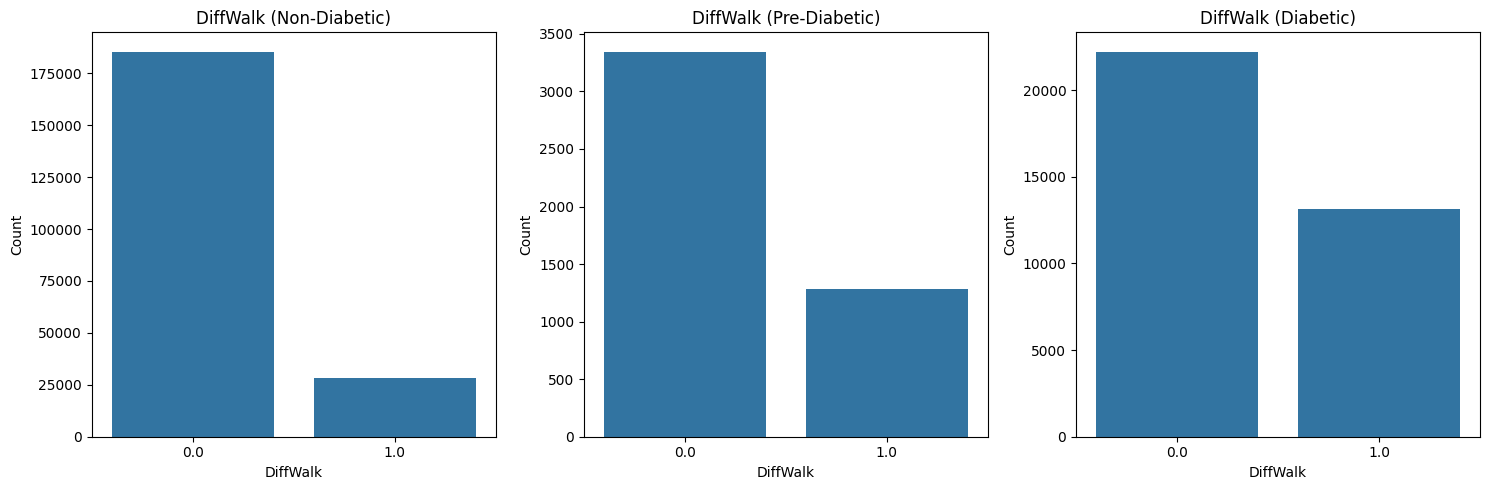

In [ ]:
diabetes_barplots("DiffWalk")
#0 = no 1 = yes
features.append("DiffWalk")

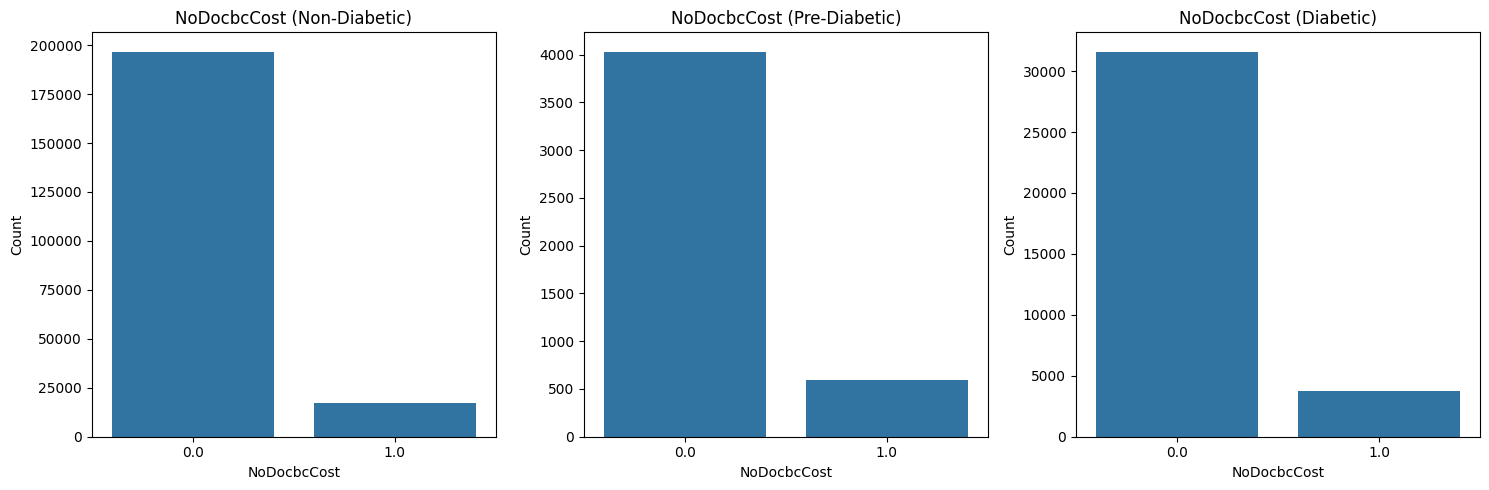

In [ ]:
diabetes_barplots("NoDocbcCost")

In [ ]:
features

['BMI',
 'Smoker',
 'HeartDiseaseorAttack',
 'PhysActivity',
 'GenHlth',
 'DiffWalk']

<font size="5"> Setting Up Training and Test Sets </font>

In [ ]:
np.random.seed(1157)

def split_test(data):
    data_len = data.shape[0]
    randomized_lst = np.random.permutation(data_len)
    shuffled_index = int(0.9 * data_len)

    test_indices = randomized_lst[shuffled_index:]
    rest_of_indices = randomized_lst[:shuffled_index]



    test = data.iloc[test_indices]
    rest = data.iloc[rest_of_indices]

    return test, rest

def split_training_val(data, training_percent):
    data_len = data.shape[0]
    randomized_lst = np.random.permutation(data_len)
    shuffled_index = int(training_percent * data_len)

    val_indices = randomized_lst[shuffled_index:]
    training_indices = randomized_lst[:shuffled_index]

    #remaining data needs to be split into validation and training. 80% of the data will be training and 20% will be validation set

    validation = data.iloc[val_indices]
    training = data.iloc[training_indices]

    return training, validation

In [ ]:
test, rest = split_test(diabetes)
train, validation = split_training_val(rest, 0.8)

In [ ]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

def rmse(y, y_train):
    return (sum((y_train - y)**2)/len(y))**0.5

def compute_CV_error(X_train, Y_train, folds=10):
    '''
    Split the training data into `k` subsets.
    For each subset,
        - Fit a model holding out that subset.
        - Compute the MSE on that subset (the validation set).
    You should be fitting `k` models in total.
    Return a list of `k` RMSEs.

    Args:
        model: An sklearn model with fit and predict functions.
        X_train (DataFrame): Training data.
        Y_train (DataFrame): Label.

    Return:
         A list of `k` RMSEs.
    '''
    model = lm.LogisticRegression(fit_intercept=True, max_iter = 1000)
    kf = KFold(n_splits=folds)
    validation_errors = []

    for train_idx, valid_idx in kf.split(X_train):
        # Split the data
        split_X_train, split_X_valid =  X_train.iloc[train_idx],  X_train.iloc[valid_idx]
        split_Y_train, split_Y_valid = Y_train.iloc[train_idx],  Y_train.iloc[valid_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(split_X_train)
        # Fit the model on the training split
        model.fit(split_X_train, split_Y_train)

        # Compute the RMSE on the validation split
        error = rmse(split_Y_valid, model.predict(split_X_valid))



        validation_errors.append(error)

    return validation_errors

In [ ]:

X_train = train[features]
Y_train = np.array(train["Diabetes_012"])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

model = lm.LogisticRegression(fit_intercept = True, max_iter = 1000 )
model.fit(X_train, Y_train)
model.predict(X_train)

training_accuracy = sum(model.predict(X_train) == Y_train)/len(Y_train)
training_accuracy



np.float64(0.8429994141769186)

In [ ]:
compute_CV_error(X_train, train["Diabetes_012"], folds = 7)

[0.7597650549473809,
 0.7689406278697148,
 0.7549831897171299,
 0.7583260807816271,
 0.7454045520336359,
 0.7565190135988205,
 0.7551245540541776]